In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==========================================================
# Automated pipeline with FIXED COLORS per ZONE for multiple timepoints
# ==========================================================

# Define main EPM directory
main_dir = Path(".").resolve()  # Should be the 'EPM' folder
timepoints = ["Preinduction", "W1", "W2"]

# Define the target EthoVision zone columns
target_zone_labels = [
    "In zone 2(O1_prevC1 / Center-point)",
    "In zone 2(O2_prevC2 / Center-point)",
    "In zone 2(C1_prevO1 / Center-point)",
    "In zone 2(C2_prevO2 / Center-point)",
    "In zone 2(NeutralZone / Center-point)",
]

# Consistent color scheme for all trials
zone_colors = {
    "In zone 2(O1_prevC1 / Center-point)": "#E41A1C",     # red
    "In zone 2(O2_prevC2 / Center-point)": "#377EB8",     # blue
    "In zone 2(C1_prevO1 / Center-point)": "#4DAF4A",     # green
    "In zone 2(C2_prevO2 / Center-point)": "#984EA3",     # purple
    "In zone 2(NeutralZone / Center-point)": "#FF7F00",   # orange
}

video_fps = 50.0
fp_fps = 50.0

# Main figures directory in EPM folder
figures_main_dir = main_dir / "Figures"
figures_main_dir.mkdir(exist_ok=True, parents=True)

# Loop through each timepoint
for tp in timepoints:
    tp_dir = main_dir / tp
    export_dir = tp_dir / "Export files"
    
    # Create subdirectory for this timepoint inside Figures
    fig_dir_tp = figures_main_dir / tp
    fig_dir_tp.mkdir(parents=True, exist_ok=True)
    
    # Subdirectory for raw ethogram figures
    fig_dir_raw = fig_dir_tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)
    
    print(f"Processing timepoint: {tp}")
    print(f"Export directory: {export_dir}")
    print(f"Figures directory: {fig_dir_raw}")
    
    # --- Here your existing processing code for each trial would go ---


Processing timepoint: Preinduction
Export directory: /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/Preinduction/Export files
Figures directory: /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/Figures/Preinduction/Raw_traces_ethograms
Processing timepoint: W1
Export directory: /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/W1/Export files
Figures directory: /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/Figures/W1/Raw_traces_ethograms
Processing timepoint: W2
Export directory: /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/W2/Export files
Figures directory: /Users/annastuckert/Documents/GitHub/FP_behaviour_analysis/EPM/Figures/W2/Raw_traces_ethograms


In [3]:

# -------------------------------------------------
# Helper functions
# -------------------------------------------------
# def _read_export_and_get_fp_id(xl_path: Path) -> str:
#     df = pd.read_excel(xl_path, header=None)
#     key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()
#     match = df[key_col == "fp file"]
#     if match.empty:
#         raise ValueError(f"'FP file' row not found in {xl_path.name}")
#     fp_id = str(df.iloc[match.index[0], 1]).strip()
#     if not fp_id or fp_id.lower() == "nan":
#         raise ValueError(f"Empty FP id in {xl_path.name}")
#     return fp_id
def _mouse_genotype_tag(mouse_id: str) -> str | None:
    """
    Map mouse ID to genotype tag.
    Returns "NE", "WT", or None if the ID is not in the mapping.
    """
    id_clean = mouse_id.strip()
    if id_clean in {"372", "376", "423"}:
        return "NE"
    if id_clean in {"374", "429"}:
        return "WT"
    return None

def _read_export_and_get_fp_and_mouse_id(xl_path: Path) -> tuple[str, str]:
    df = pd.read_excel(xl_path, header=None)
    key_col = df.iloc[:, 0].astype(str).str.strip().str.lower()

    # FP file
    match_fp = df[key_col == "fp file"]
    if match_fp.empty:
        raise ValueError(f"'FP file' row not found in {xl_path.name}")
    fp_id = str(df.iloc[match_fp.index[0], 1]).strip()
    if not fp_id or fp_id.lower() == "nan":
        raise ValueError(f"Empty FP id in {xl_path.name}")

    # Mouse ID
    match_id = df[key_col == "id"]
    if match_id.empty:
        raise ValueError(f"'ID' row not found in {xl_path.name}")

    mouse_id = str(df.iloc[match_id.index[0], 1]).strip()
    if not mouse_id or mouse_id.lower() == "nan":
        raise ValueError(f"Empty mouse ID in {xl_path.name}")

    return fp_id, mouse_id


def _find_fp_and_timestamp_files(fp_folder: Path, fp_id: str) -> tuple[Path, Path]:
    fp_candidates = list(fp_folder.glob(f"{fp_id}.csv"))
    if not fp_candidates:
        fp_candidates = [p for p in fp_folder.glob("*.csv") if fp_id.lower() in p.name.lower()]
    if not fp_candidates:
        raise FileNotFoundError(f"No FP csv in {fp_folder} for id {fp_id}")
    fp_csv = sorted(fp_candidates)[0]
    ts_candidates = list(fp_folder.glob("timestamp*.csv"))
    if not ts_candidates:
        ts_candidates = [p for p in fp_folder.glob("*.csv") if "time" in p.name.lower()]
    if not ts_candidates:
        raise FileNotFoundError(f"No timestamp csv in {fp_folder}")
    ts_csv = sorted(ts_candidates)[0]
    return fp_csv, ts_csv

def _coerce_bool_col(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int).astype(bool)
    low = series.astype(str).str.strip().str.lower()
    return low.isin(["true", "1", "t", "yes", "y"])

def _get_video_window(ts: pd.DataFrame) -> tuple[float, float]:
    state_col = "DigitalIOState" if "DigitalIOState" in ts.columns else next(
        c for c in ts.columns if "digital" in c.lower() or "state" in c.lower()
    )
    time_col = "SystemTimestamp" if "SystemTimestamp" in ts.columns else next(
        c for c in ts.columns if "time" in c.lower()
    )
    state = _coerce_bool_col(ts[state_col])
    t = pd.to_numeric(ts[time_col], errors="coerce")
    if state.sum() == 0 or (~state).sum() == 0:
        raise ValueError("Timestamp must contain at least one True and one False in DigitalIOState")
    video_start = float(t[state].iloc[0])
    video_stop = float(t[~state].iloc[0])
    if not np.isfinite(video_start) or not np.isfinite(video_stop) or video_stop <= video_start:
        video_start = float(np.nanmin(t[state]))
        video_stop = float(np.nanmax(t[~state]))
    return video_start, video_stop

def _build_time_vector_from_fp(fp_df: pd.DataFrame) -> np.ndarray:
    if "SystemTimestamp" in fp_df.columns:
        tt = pd.to_numeric(fp_df["SystemTimestamp"], errors="coerce").to_numpy()
        if np.isfinite(tt).sum() >= len(tt) * 0.8:
            return tt
    return np.arange(len(fp_df), dtype=float) / fp_fps

def _snap_down_index(t: np.ndarray, target: float) -> int:
    return max(0, np.searchsorted(t, target, side="right") - 1)

def _trim_fp_to_window(fp_df: pd.DataFrame, start: float, stop: float) -> pd.DataFrame:
    tt = _build_time_vector_from_fp(fp_df)
    if len(tt) != len(fp_df):
        n = min(len(tt), len(fp_df))
        tt = tt[:n]
        fp_df = fp_df.iloc[:n, :].reset_index(drop=True)
    i0 = _snap_down_index(tt, start)
    i1 = _snap_down_index(tt, stop)
    i1 = max(i1, i0)
    out = fp_df.iloc[i0:i1+1, :].copy()
    out["Time_video"] = tt[i0:i1+1] - tt[i0]
    return out

_norm = re.compile(r"[^a-z0-9]+")
def _norm_key(s: str) -> str:
    return _norm.sub("", s.lower())

def _load_ethovision_sheet_with_targets(eth_path: Path, targets: list[str], video_fps: float):
    """
    Load EthoVision sheet and automatically detect the header row
    by finding the first column containing 'Trial time'.
    """
    # Read first 100 rows of first column to find header
    preview = pd.read_excel(eth_path, usecols=[0], nrows=100, header=None)
    header_row = preview[preview.iloc[:, 0].astype(str).str.contains("Trial time", case=False, na=False)].index
    if len(header_row) == 0:
        raise ValueError(f"Could not find 'Trial time' in first column of {eth_path.name}")
    header_row = header_row[0]

    # Read full sheet with detected header
    eth = pd.read_excel(eth_path, header=header_row).dropna(axis=1, how="all")

    # Match target columns
    norm_map = {_norm_key(c): c for c in eth.columns}
    matched_cols = [norm_map[_norm_key(t)] for t in targets if _norm_key(t) in norm_map]

    if not matched_cols:
        raise ValueError(f"No zone columns found in {eth_path.name}")

    # Add Time_s
    time_col = next((c for c in eth.columns if "time" in str(c).lower()), None)
    if time_col is None:
        eth["Time_s"] = np.arange(len(eth)) / video_fps
    else:
        eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

    return eth[["Time_s"] + matched_cols].copy(), matched_cols


# def _load_ethovision_sheet_with_targets(eth_path: Path, targets: list[str], video_fps: float):
#     eth = pd.read_excel(eth_path, header=38).dropna(axis=1, how="all")
#     time_col = next((c for c in eth.columns if "time" in str(c).lower()), None)
#     if time_col is None:
#         eth["Time_s"] = np.arange(len(eth)) / video_fps
#     else:
#         eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")
#     norm_map = {_norm_key(c): c for c in eth.columns}
#     found_cols = []
#     for label in targets:
#         key = _norm_key(label)
#         if key in norm_map:
#             found_cols.append(norm_map[key])
#         else:
#             candidates = [c for k, c in norm_map.items() if key in k]
#             if candidates:
#                 found_cols.append(candidates[0])
#     return eth[["Time_s"] + found_cols].copy(), found_cols

def _ethogram_segments(eth: pd.DataFrame, beh_cols: list[str]) -> pd.DataFrame:
    segs = []
    for beh in beh_cols:
        mask = (eth[beh] == 1)
        if mask.sum() == 0:
            continue
        diff = mask.astype(int).diff().fillna(0)
        starts = eth.loc[diff == 1, "Time_s"].values
        ends = eth.loc[diff == -1, "Time_s"].values
        if mask.iloc[0]:
            starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
        if mask.iloc[-1]:
            ends = np.append(ends, eth["Time_s"].iloc[-1])
        for s, e in zip(starts, ends):
            segs.append({"Behavior": beh, "Start_time_s": float(s), "End_time_s": float(e), "Duration_s": float(e - s)})
    if not segs:
        return pd.DataFrame(columns=["Behavior", "Start_time_s", "End_time_s", "Duration_s"])
    return pd.DataFrame(segs).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

def _plot_trial(fp_trim: pd.DataFrame, eth_timeline: pd.DataFrame, beh_cols: list[str], out_png: Path, title_prefix: str):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 2, 1]})

    if "LedState" not in fp_trim.columns:
        raise ValueError("FP csv must contain 'LedState' with values 1 and 2")

    chan = "G0" if "G0" in fp_trim.columns else next(
        c for c in fp_trim.columns if pd.api.types.is_numeric_dtype(fp_trim[c]) and c not in {"SystemTimestamp","LedState","Time_video","Time_s","Timestamp"}
    )

    # --- LED 1 (isosbestic) ---
    fp1 = fp_trim[fp_trim["LedState"] == 1]
    axes[0].plot(fp1["Time_video"], fp1[chan], linewidth=0.8, color="gray")
    axes[0].set_ylabel(f"{chan} (LED 1 Isosbestic)")
    axes[0].set_title(f"{title_prefix}: LED 1")
    axes[0].grid(True)

    # --- LED 2 (GCaMP) ---
    fp2 = fp_trim[fp_trim["LedState"] == 2]
    axes[1].plot(fp2["Time_video"], fp2[chan], linewidth=0.8, color="green")
    axes[1].set_ylabel(f"{chan} (LED 2 GCaMP)")
    axes[1].set_title(f"{title_prefix}: LED 2")
    axes[1].grid(True)

    # --- Ethogram (zones) ---
    if eth_timeline is not None and not eth_timeline.empty:
        behaviors = beh_cols
        for i, beh in enumerate(behaviors):
            sub = eth_timeline[eth_timeline["Behavior"] == beh]
            color = zone_colors.get(beh, f"C{i}")  # fallback if missing
            for _, row in sub.iterrows():
                axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"], height=0.6, color=color)
        axes[2].set_yticks(range(len(behaviors)))
        axes[2].set_yticklabels(behaviors)
        axes[2].set_xlabel("Time (s)")
        axes[2].set_title("Time-in-zone ethogram (fixed colors)")
        axes[2].invert_yaxis()

    axes[-1].set_xlim(fp_trim["Time_video"].min(), fp_trim["Time_video"].max())
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close(fig)

    # -------------------------------------------------
# Helper to extract and store LED-specific traces
# -------------------------------------------------
def _extract_led_traces(fp_trim: pd.DataFrame, chan: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Extract 415 nm (isosbestic) and 470 nm (GCaMP) traces for a given channel
    from a trimmed FP dataframe (fp_trim).
    Returns: (iso_df, gcamp_df)
    """
    if "LedState" not in fp_trim.columns:
        raise ValueError("FP dataframe must contain 'LedState' column")

    # 415 nm → LED 1 (isosbestic)
    iso_df = fp_trim.loc[fp_trim["LedState"] == 1, ["Time_video", chan]].copy()
    iso_df.rename(columns={chan: f"{chan}_iso415"}, inplace=True)

    # 470 nm → LED 2 (GCaMP)
    gcamp_df = fp_trim.loc[fp_trim["LedState"] == 2, ["Time_video", chan]].copy()
    gcamp_df.rename(columns={chan: f"{chan}_gcamp470"}, inplace=True)

    return iso_df.reset_index(drop=True), gcamp_df.reset_index(drop=True)


# GUPPY PIPELINE 

# Generate plots of each trial where the FP signal is cut to the timeframe of the ethovision video, and it is plotted against an ethogram of the ethovision video

In [6]:
# ==========================================================
# Main processing loop for all timepoints
# ==========================================================

# Dictionary to collect isosbestic and GCaMP traces for all trials across timepoints
fp_traces = {}

for tp in timepoints:
    tp_dir = main_dir / tp
    export_dir = tp_dir / "Export files"
    
    # Figures folder for this timepoint
    fig_dir_tp = figures_main_dir / tp
    fig_dir_raw = fig_dir_tp / "Raw_traces_ethograms"
    fig_dir_raw.mkdir(parents=True, exist_ok=True)
    
    # Find all trial export files
    trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
    if not trial_files:
        print(f"[WARN] No 'Raw data-*.xlsx' files found in {export_dir}")
        continue

    for eth_path in trial_files:
        try:
            # --- Read FP ID and locate FP files ---
            fp_id, mouse_id = _read_export_and_get_fp_and_mouse_id(eth_path)
            geno_tag = _mouse_genotype_tag(mouse_id)

            fp_folder = tp_dir / fp_id

            if not fp_folder.is_dir():
                raise FileNotFoundError(f"FP folder not found: {fp_folder}")
            fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)

            # --- Load FP data ---
            fp = pd.read_csv(fp_csv)
            fp = fp[fp["LedState"].isin([1, 2])].copy()

            ts = pd.read_csv(ts_csv)
            video_start, video_stop = _get_video_window(ts)
            fp_trim = _trim_fp_to_window(fp, start=video_start, stop=video_stop)

            # --- Detect signal channel ---
            chan = "G0" if "G0" in fp_trim.columns else next(
                c for c in fp_trim.columns
                if pd.api.types.is_numeric_dtype(fp_trim[c])
                and c not in {"SystemTimestamp", "LedState", "Time_video", "Time_s", "Timestamp"}
            )

            # # --- Extract LED traces ---
            # iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)
            # trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")
            # key = f"{tp}__{fp_id}__{trial_stub}"  # include timepoint in key
            # fp_traces[key] = {"iso": iso_df, "gcamp": gcamp_df}
            iso_df, gcamp_df = _extract_led_traces(fp_trim, chan)

            trial_stub = eth_path.stem.replace("Raw data-", "").replace(" ", "_")

            # Build a common stub that always includes mouse ID, and genotype if available
            if geno_tag is not None:
                mouse_part = f"ID{mouse_id}_{geno_tag}"
            else:
                mouse_part = f"ID{mouse_id}"

            file_stub = f"{mouse_part}__{fp_id}__{trial_stub}"

            # Key for the traces dictionary (also contains timepoint)
            key = f"{tp}__{file_stub}"
            fp_traces[key] = {
                "iso": iso_df,
                "gcamp": gcamp_df,
                "mouse_id": mouse_id,
                "genotype": geno_tag,
            }


            # --- Load ethovision data and extract ethogram ---
            eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, target_zone_labels, video_fps)
            if not matched_cols:
                raise ValueError(f"No zone columns found in {eth_path.name}")
            timeline = _ethogram_segments(eth, matched_cols)

            # # --- Plot trial ---
            # out_png = fig_dir_raw / f"{fp_id}__{trial_stub}_zones.png"
            # _plot_trial(fp_trim, timeline, matched_cols, out_png, title_prefix=f"{fp_id} — {trial_stub}")
            # print(f"✅ [{tp}] {eth_path.name} → {fp_id} | Figure: {out_png.name}")
            out_png = fig_dir_raw / f"{file_stub}_zones.png"
            _plot_trial(
                fp_trim,
                timeline,
                matched_cols,
                out_png,
                title_prefix=f"{mouse_part} | {fp_id} | {trial_stub}",
            )
            

        except Exception as e:
            print(f"[WARN] [{tp}] {eth_path.name}: {e}")


In [7]:
# Example: list all traces for Preinduction
tp = "W1"
preinduction_keys = [k for k in fp_traces.keys() if k.startswith(f"{tp}__")]
print(preinduction_keys)

# Access the first trace for this timepoint
first_key = preinduction_keys[0]
iso_df = fp_traces[first_key]["iso"]
gcamp_df = fp_traces[first_key]["gcamp"]

print(iso_df.head())
print(gcamp_df.head())


['W1__ID376_NE__EPM_FP0__EPM_W1-Trial_____1', 'W1__ID372_NE__EPM_FP1__EPM_W1-Trial_____2', 'W1__ID374_WT__EPM_FP2__EPM_W1-Trial_____3', 'W1__ID429_WT__EPM_FP3__EPM_W1-Trial_____4', 'W1__ID423_NE__EPM_FP4__EPM_W1-Trial_____5']
   Time_video  G0_iso415
0        0.00   0.032032
1        0.04   0.031962
2        0.08   0.031995
3        0.12   0.031930
4        0.16   0.031892
   Time_video  G0_gcamp470
0        0.02     0.033959
1        0.06     0.033862
2        0.10     0.033953
3        0.14     0.033923
4        0.18     0.033964


# code for manually subtracting iso from gcamp by aligning iso and gcamp to occur at same timepoints (a bit artificial, they do not occur at exactly the same timepoint)

In [ ]:
# ==========================================================
# Coregister ISO and GCaMP traces for all timepoints
# ==========================================================

import pandas as pd

def coregister_iso_gcamp(trial_traces: dict) -> pd.DataFrame:
    """
    trial_traces: dict with keys 'iso' and 'gcamp', each a DataFrame like:
        iso:   ['Time_video', 'G0_iso415']
        gcamp:['Time_video', 'G0_gcamp470']

    Returns one DataFrame with:
        Time_video  (from the channel that starts first)
        iso415
        gcamp470
    """
    iso = trial_traces["iso"].copy()
    gcamp = trial_traces["gcamp"].copy()

    # Get signal column names
    iso_col   = [c for c in iso.columns   if c != "Time_video"][0]
    gcamp_col = [c for c in gcamp.columns if c != "Time_video"][0]

    # Trim to common length just in case
    n = min(len(iso), len(gcamp))
    iso   = iso.iloc[:n].reset_index(drop=True)
    gcamp = gcamp.iloc[:n].reset_index(drop=True)

    # Decide which channel is "main" based on starting time
    if gcamp["Time_video"].iloc[0] <= iso["Time_video"].iloc[0]:
        # gcamp starts first → use its time
        time_main = gcamp["Time_video"].values
    else:
        # iso starts first → use its time
        time_main = iso["Time_video"].values

    aligned = pd.DataFrame({
        "Time_video": time_main,
        "iso415": iso[iso_col].values,
        "gcamp470": gcamp[gcamp_col].values,
    })

    return aligned

# -------------------------------------------------
# Apply coregistration to all trials in fp_traces
# -------------------------------------------------

coregistered_traces = {}  # store results per trial

for tp in timepoints:
    # Filter keys for this timepoint
    tp_keys = [k for k in fp_traces.keys() if k.startswith(f"{tp}__")]
    for k in tp_keys:
        try:
            aligned_df = coregister_iso_gcamp(fp_traces[k])
            coregistered_traces[k] = aligned_df
        except Exception as e:
            print(f"[WARN] Could not coregister {k}: {e}")

# Example access:


# apply zero-phase moving window - not using subtracted data

After extraction of the data, a zero-phase moving average linear digital filter is applied backwards and forwards to both the channels to reduce high frequency noise without time-shifting. The standard window for the moving filter is 100 data points i GuPPy, but can be adjusted by the user when setting input parameters. The window needs to be adjusted depending on the sampling rate of the recorded data. Guidelines are provided in the user guide. The traces resulting after this filtering step will be displayed for the user to inspect before proceeding with analysis.

In [10]:
import numpy as np
from scipy.signal import filtfilt

def zero_phase_moving_average(signal, window_pts=5):
    """
    GuPPy-style zero-phase moving average.

    signal: 1D array-like
    window_pts: length of moving average window in samples.
                For your data (~25 Hz), 100 pts ≈ 4 seconds.
    """
    signal = np.asarray(signal, dtype=float)

    if window_pts < 1:
        raise ValueError("window_pts must be >= 1")

    # Moving average kernel
    kernel = np.ones(window_pts, dtype=float) / window_pts

    # Zero-phase: forward + backward filtering
    filtered = filtfilt(kernel, [1.0], signal, padlen=3 * window_pts)
    return filtered

# ==========================================================
# Apply zero-phase moving average to all aligned trials
# ==========================================================

smoothed_trials = {}

# window_pts can be adjusted per your data; default is 100
window_pts = 100

for key, df in aligned_trials.items():
    try:
        smoothed_df = df.copy()
        smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
        smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
        smoothed_trials[key] = smoothed_df
    except Exception as e:
        print(f"[WARN] Could not smooth trial {key}: {e}")

# Example: check one smoothed trial
example_key = list(smoothed_trials.keys())[0]
print(f"Example smoothed trial: {example_key}")
print(smoothed_trials[example_key].head())


NameError: name 'aligned_trials' is not defined

Nice, you found the key bit in their methods. That paragraph is describing what happens on the TDT rig, not in GuPPy itself:
465 nm and 405 nm LEDs … were demodulated using a 4 Hz low-pass frequency filter.
So there are actually two separate filtering stages in their setup:
Hardware / Synapse side (TDT)
LEDs modulated at ~200–330 Hz
Demodulated and low-pass filtered at 4 Hz on the RZ5P
This already strips out the fast carrier and most high-frequency noise
Software side (GuPPy)
GuPPy then adds a zero-phase moving average filter with a user-defined window (default 100 points) on the demodulated streams
The “Window for Moving Average filter” in GuPPy refers to step 2.
How to think about window_pts in terms of your sampling rate
​	
Larger M → lower cutoff → more aggressive smoothing
Smaller M → higher cutoff → lighter smoothing
What did GuPPy likely do in their own rig?
On TDT they say “demodulated using a 4 Hz low-pass filter”. If their demodulated stream was at around 1 kHz (typical for RZ5P), then:

​	
 ≈4.4 Hz
So a 100-point moving average at ~1 kHz naturally gives about a 4 Hz cutoff, which matches their description.
In your case, though, you’re working with already demultiplexed / downsampled FP3002-style traces at ~25 Hz per channel.
What is “appropriate” for 25 Hz per channel?

​	
 
Some example window_pts:
M (window_pts)	f_c (approx)	Smoothed time scale
3	~3.7 Hz	very light smoothing, almost raw
5	~2.2 Hz	light smoothing
11	~1.0 Hz	moderate smoothing over ~1 s
25	~0.44 Hz	strong smoothing over several seconds
75	~0.15 Hz	very slow trend only, kills fast dynamics

Start with window_pts = 5–11
5 points → f_c ≈ 2.2 Hz (light smoothing)
11 points → f_c ≈ 1.0 Hz (moderate smoothing)

In [19]:
# ==========================================================
# Apply zero-phase moving average to all coregistered trials
# ==========================================================

smoothed_trials = {}

# window_pts can be adjusted per your data; default is 100
window_pts = 5

for key, df in coregistered_traces.items():   # <-- use coregistered_traces
    try:
        smoothed_df = df.copy()
        smoothed_df["iso415_smooth"]   = zero_phase_moving_average(df["iso415"].values, window_pts)
        smoothed_df["gcamp470_smooth"] = zero_phase_moving_average(df["gcamp470"].values, window_pts)
        smoothed_trials[key] = smoothed_df
    except Exception as e:
        print(f"[WARN] Could not smooth trial {key}: {e}")

# Example: check one smoothed trial
example_key = list(smoothed_trials.keys())[0]
print(f"Example smoothed trial: {example_key}")
print(smoothed_trials[example_key].head())


Example smoothed trial: Preinduction__ID376_NE__EPM_FP0__EPM_Preinduction-Trial_____1
   Time_video    iso415  gcamp470  iso415_smooth  gcamp470_smooth
0        0.00  0.033076  0.033753       0.033076         0.033753
1        0.04  0.033114  0.033775       0.033088         0.033706
2        0.08  0.033101  0.033609       0.033095         0.033650
3        0.12  0.033125  0.033639       0.033100         0.033592
4        0.16  0.033103  0.033542       0.033102         0.033532


If you want to process ISO and GCaMP separately (without merging/alignment), you can compute filtered traces only or optionally z-score each independently. ∆F/F won’t make sense without alignment, but you can still smooth and analyze each channel.

In [20]:
import numpy as np

dFF_trials = {}

for key, df in smoothed_trials.items():  # <-- use smoothed_trials
    df = df.copy()

    # 1) Take filtered iso (control) and gcamp (signal) traces as numpy arrays
    x = df["iso415_smooth"].to_numpy()   # control (405)
    y = df["gcamp470_smooth"].to_numpy() # signal (470)

    # 2) Mask out NaNs or infs
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    # 3) Least squares linear regression: y ≈ a*x + b
    if len(x_fit) < 2:
        print(f"[WARN] Not enough valid points to fit trial {key}")
        continue
    a, b = np.polyfit(x_fit, y_fit, 1)

    # 4) Fitted control trace for all points
    Y_fit_all = a * x + b

    # 5) Delta F = signal − fitted control
    Y_dF_all = y - Y_fit_all

    # 6) ∆F/F (%) = 100 * (ΔF / fitted control)
    eps = np.finfo(float).eps  # avoid division by zero
    dFF = 100.0 * (Y_dF_all / (Y_fit_all + eps))

    # 7) Store results in DataFrame
    df["iso_fit"] = Y_fit_all       # fitted baseline
    df["dFF"]     = dFF             # ∆F/F in percent

    # 8) Optional: z-score the dF/F
    mu  = np.nanmean(dFF)
    sig = np.nanstd(dFF)
    df["dFF_z"] = (dFF - mu) / sig if sig > 0 else np.zeros_like(dFF)

    # Update trial in dictionary
    dFF_trials[key] = df

# Example: inspect one trial
example_key = list(dFF_trials.keys())[0]
print(f"Example dF/F processed trial: {example_key}")
print(dFF_trials[example_key].head())


Example dF/F processed trial: Preinduction__ID376_NE__EPM_FP0__EPM_Preinduction-Trial_____1
   Time_video    iso415  gcamp470  iso415_smooth  gcamp470_smooth   iso_fit  \
0        0.00  0.033076  0.033753       0.033076         0.033753  0.033490   
1        0.04  0.033114  0.033775       0.033088         0.033706  0.033526   
2        0.08  0.033101  0.033609       0.033095         0.033650  0.033548   
3        0.12  0.033125  0.033639       0.033100         0.033592  0.033563   
4        0.16  0.033103  0.033542       0.033102         0.033532  0.033571   

        dFF     dFF_z  
0  0.786764  0.560178  
1  0.538408  0.383345  
2  0.302232  0.215184  
3  0.085759  0.061052  
4 -0.116502 -0.082961  


what you’re plotting is not the regression line in 2D space, but the 405 time-series passed through the regression model.

In [22]:
import numpy as np

preproc_trials = {}

for key, df in smoothed_trials.items():
    df = df.copy()

    # Take smoothed iso (control) and gcamp (signal)
    x = df["iso415_smooth"].to_numpy()
    y = df["gcamp470_smooth"].to_numpy()

    # Mask invalid values
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) < 2:
        print(f"[WARN] Not enough valid points for trial {key}")
        continue

    # Linear regression: y ≈ a*x + b
    a, b = np.polyfit(x_fit, y_fit, 1)

    # Fitted baseline
    Y_fit_all = a * x + b

    # Delta F
    Y_dF_all = y - Y_fit_all

    # ∆F/F (%)
    eps = np.finfo(float).eps
    dFF = 100.0 * (Y_dF_all / (Y_fit_all + eps))

    # z-scored ∆F/F
    mu  = np.nanmean(dFF)
    sig = np.nanstd(dFF)
    dFF_z = (dFF - mu)/sig if sig > 0 else np.zeros_like(dFF)

    # Store in DataFrame
    df["iso_fit"] = Y_fit_all
    df["dFF"] = dFF
    df["dFF_z"] = dFF_z

    preproc_trials[key] = df


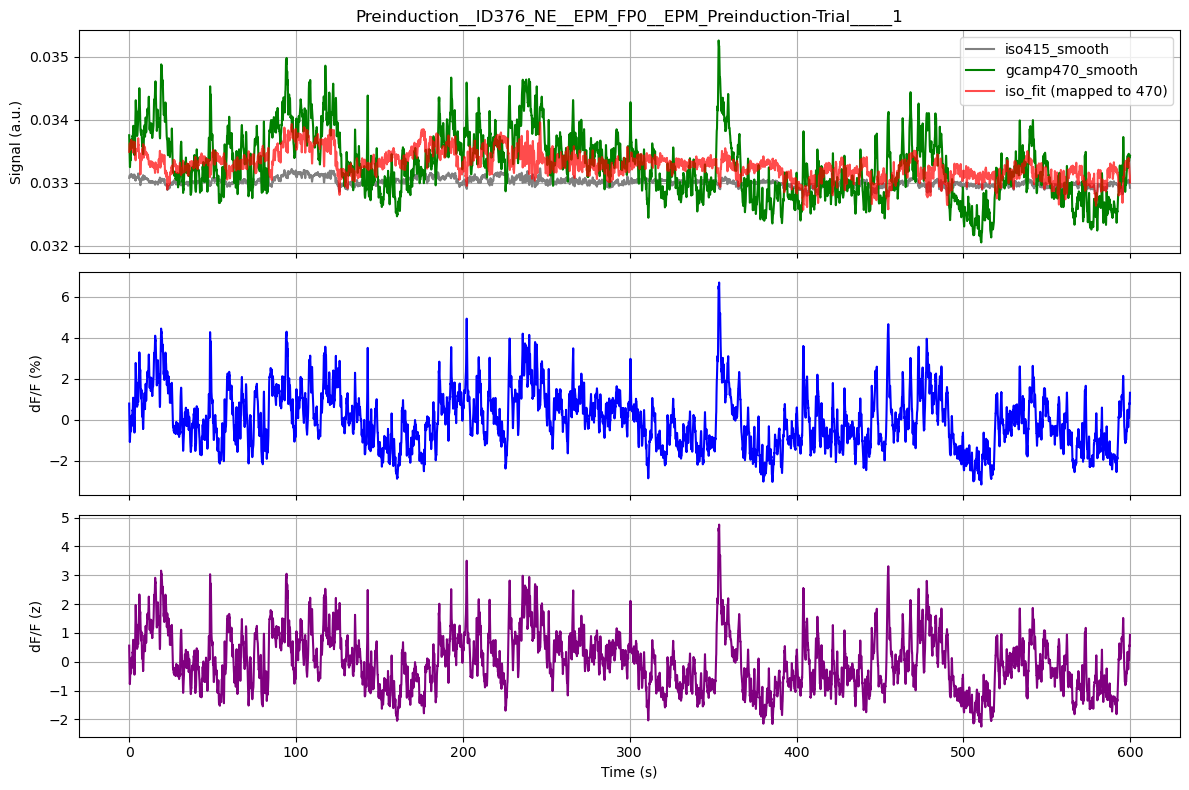

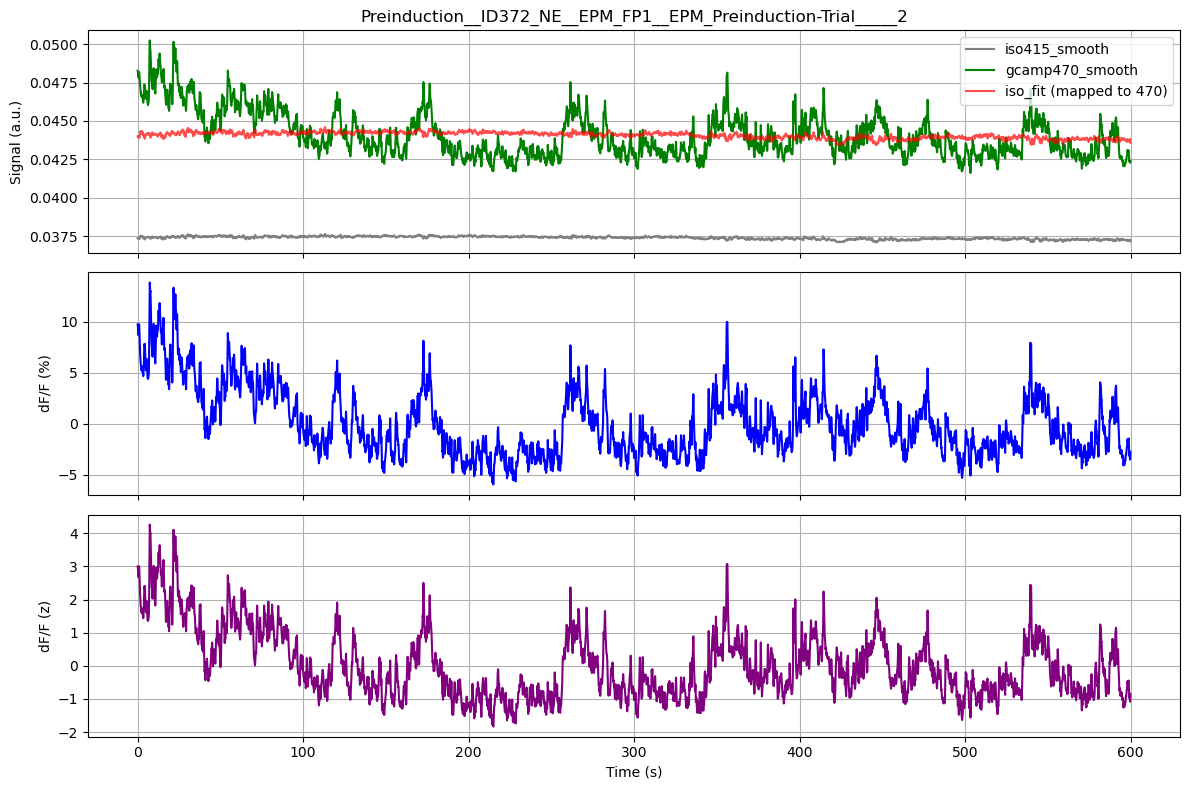

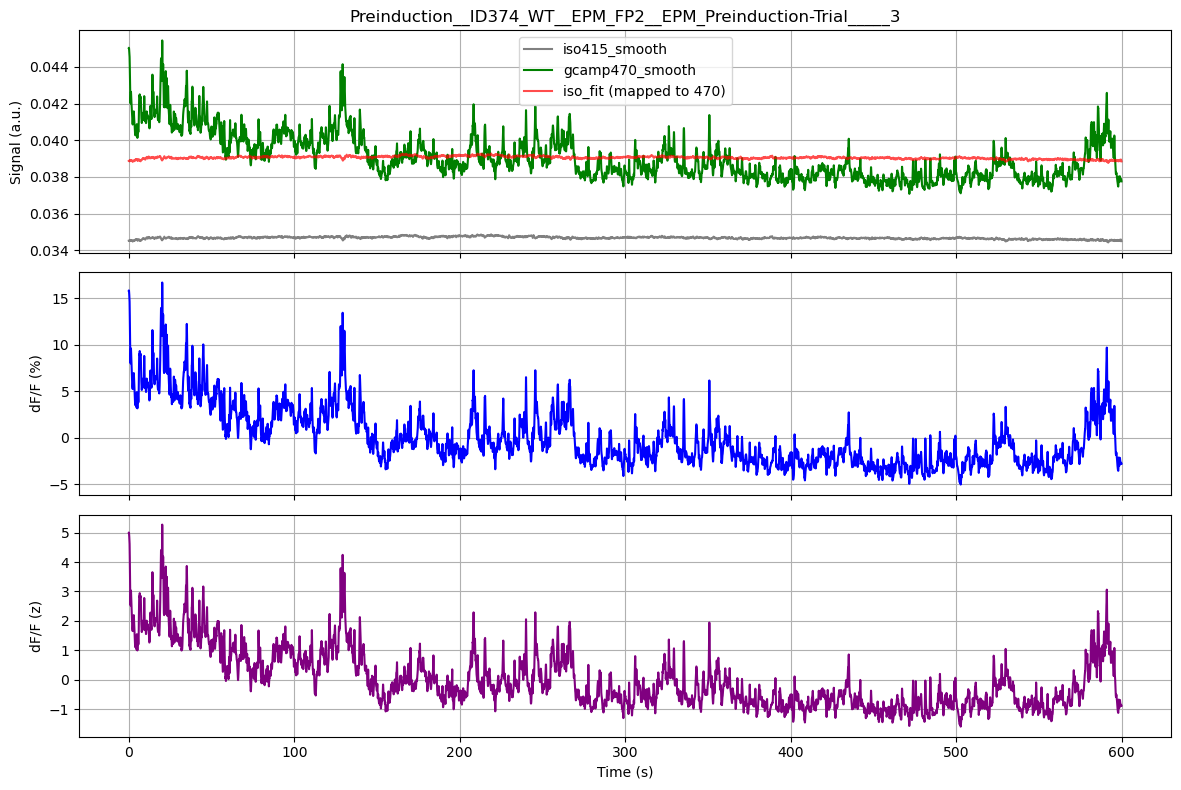

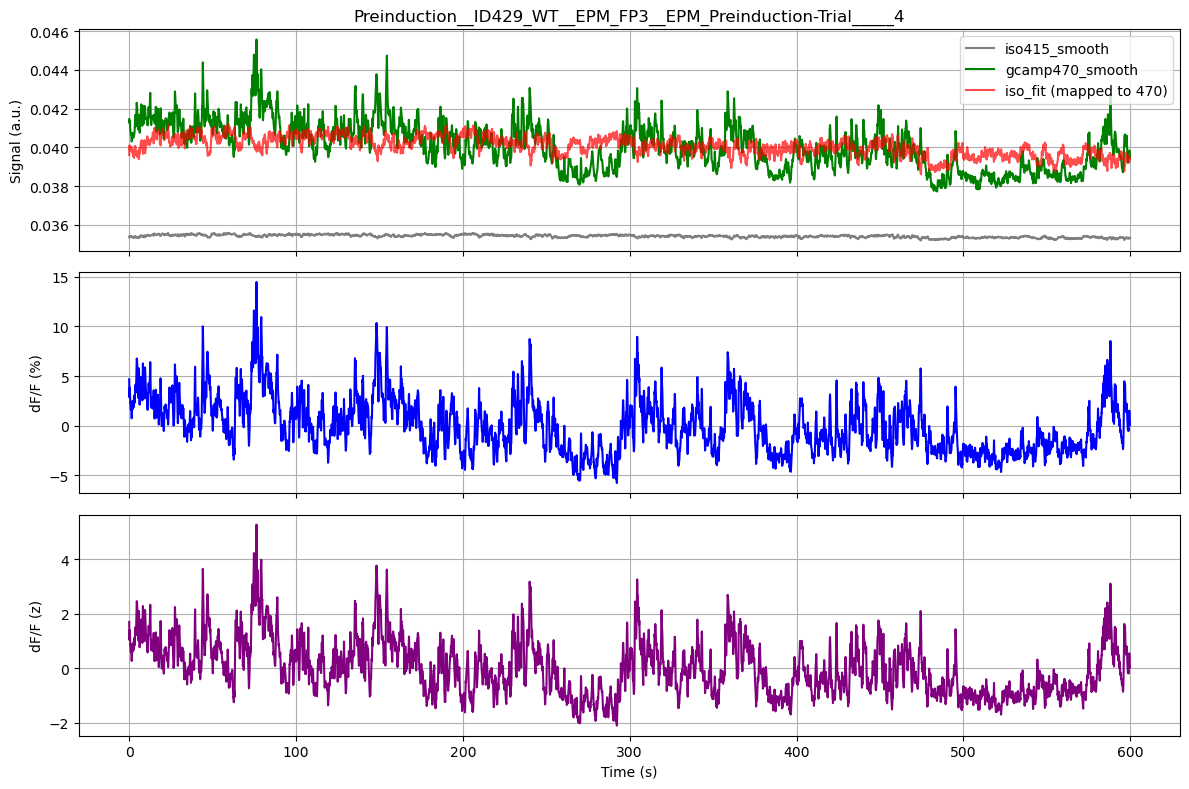

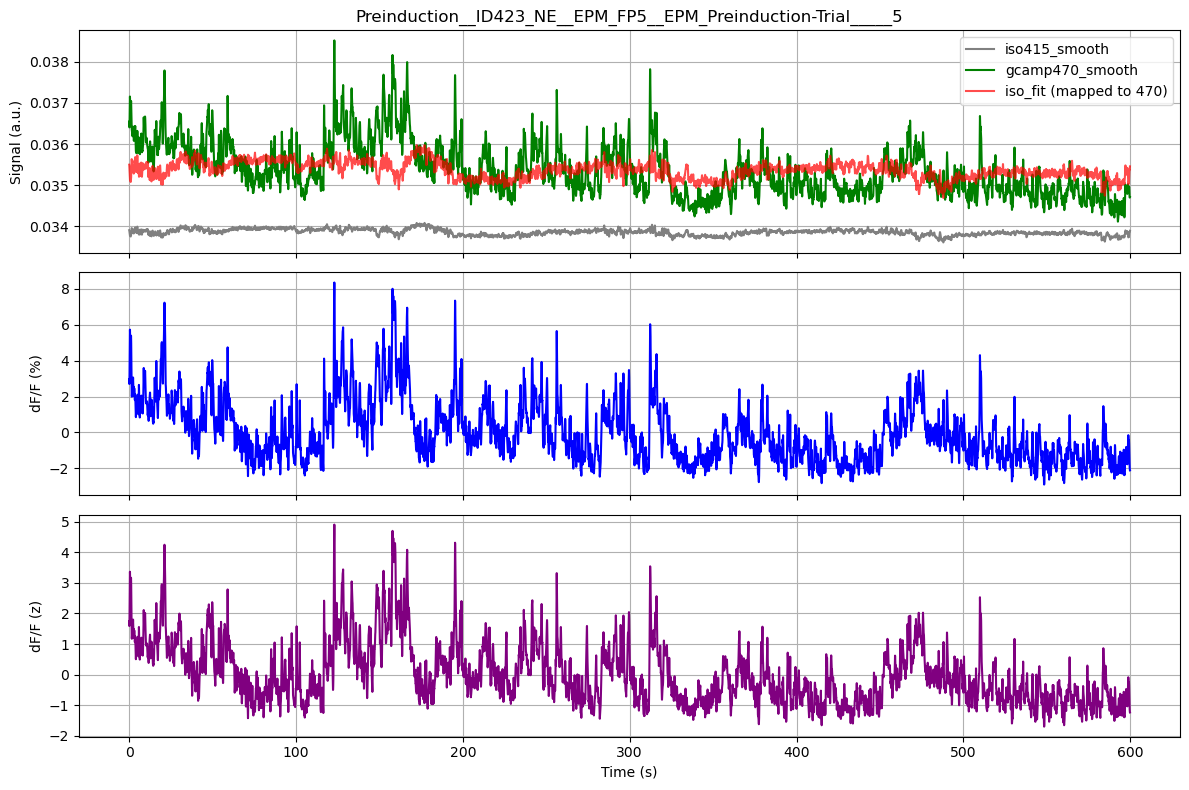

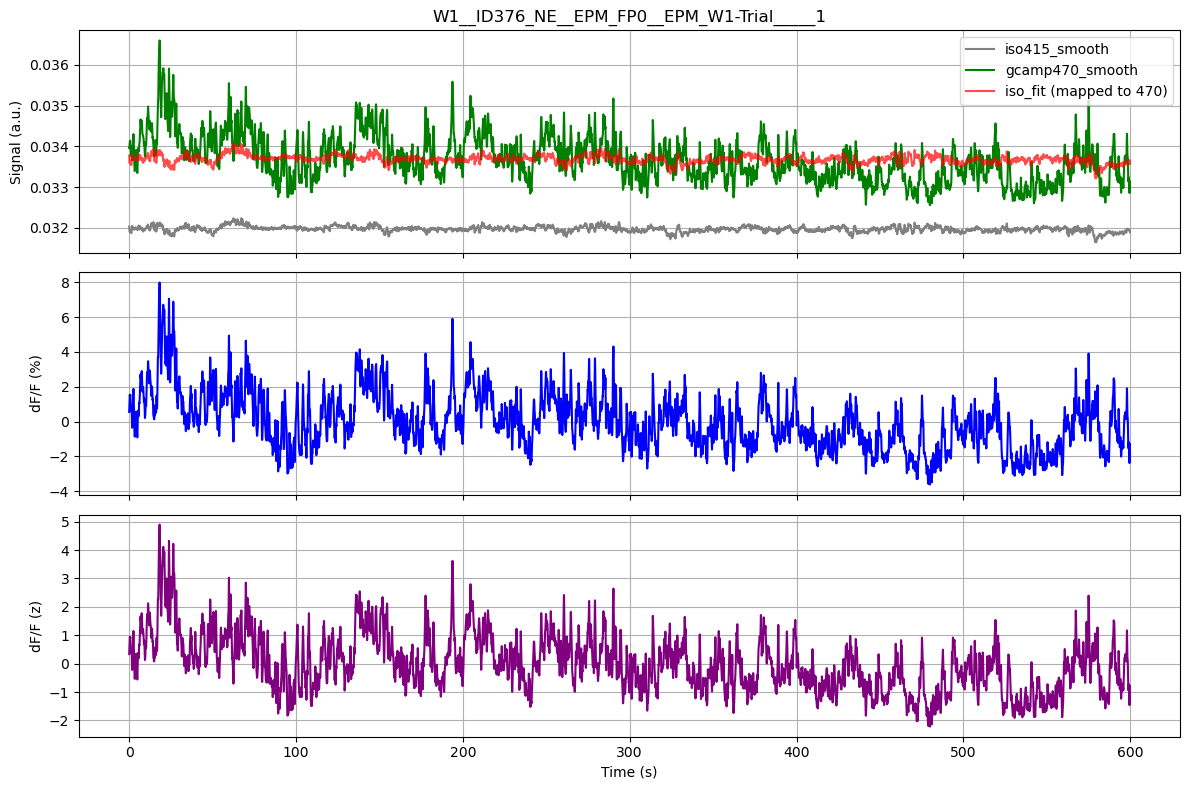

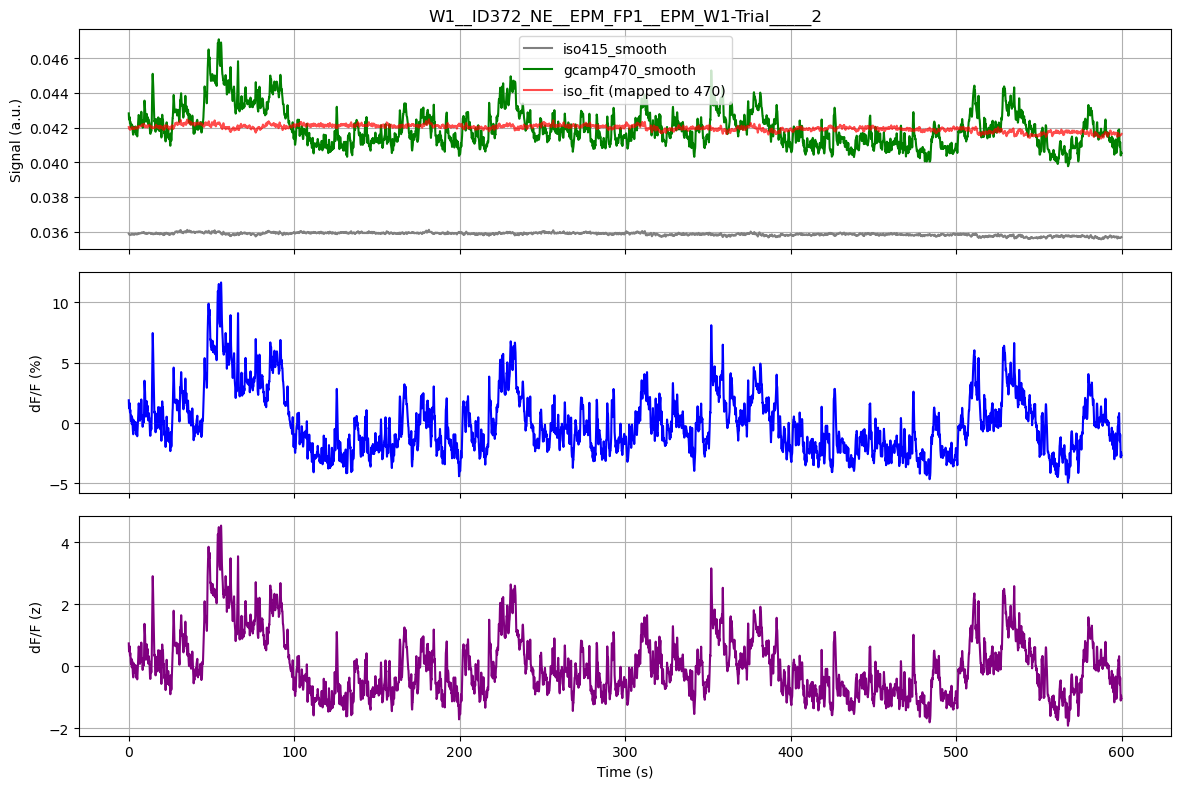

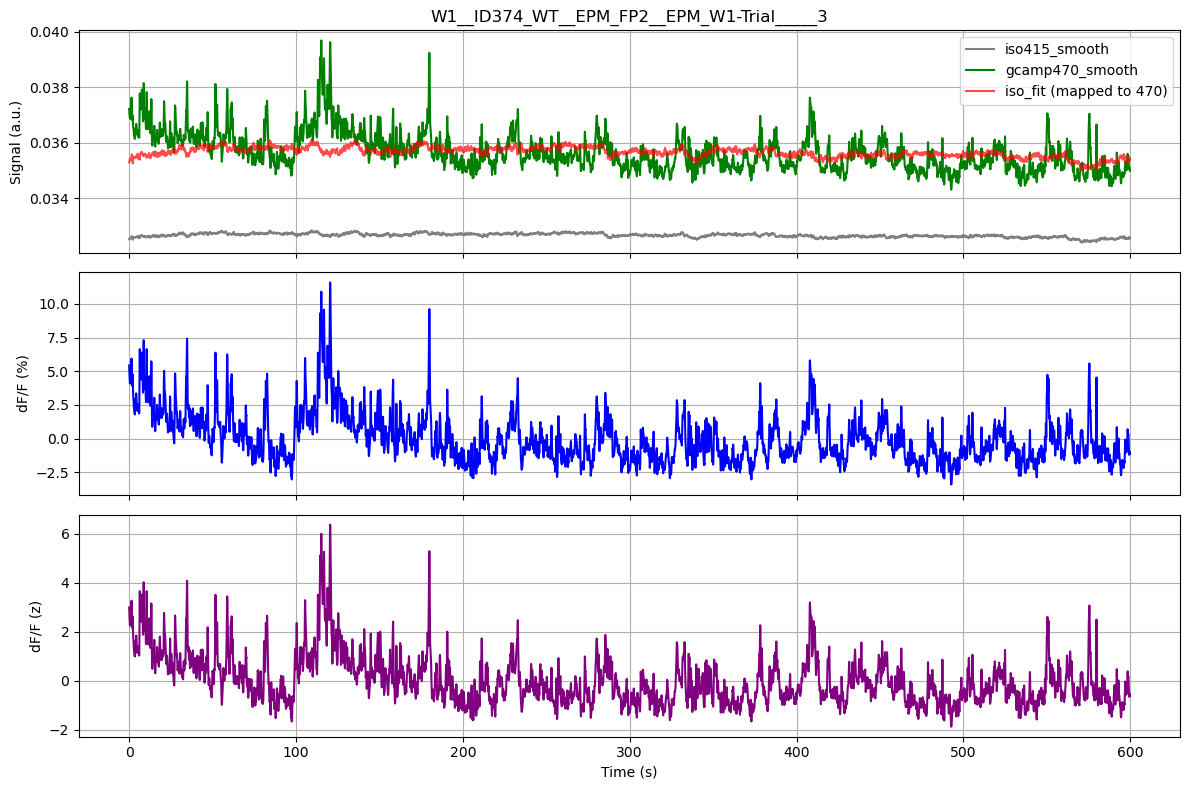

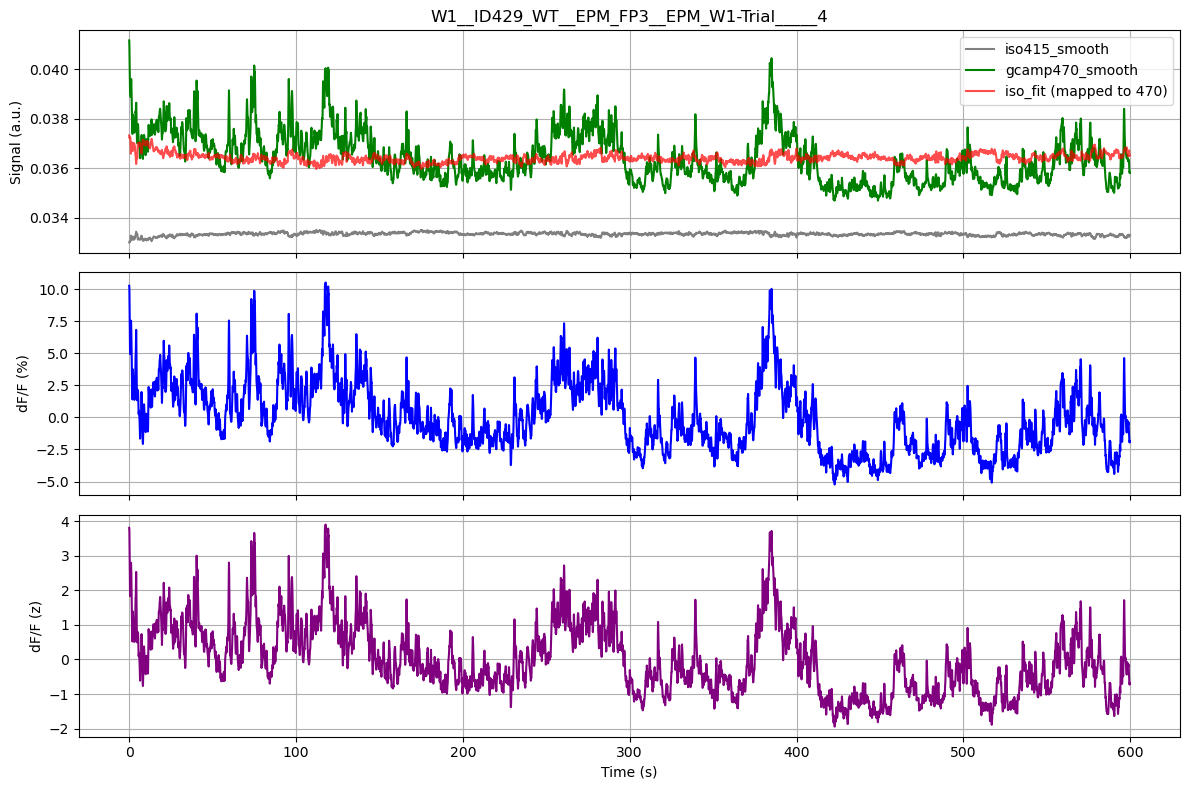

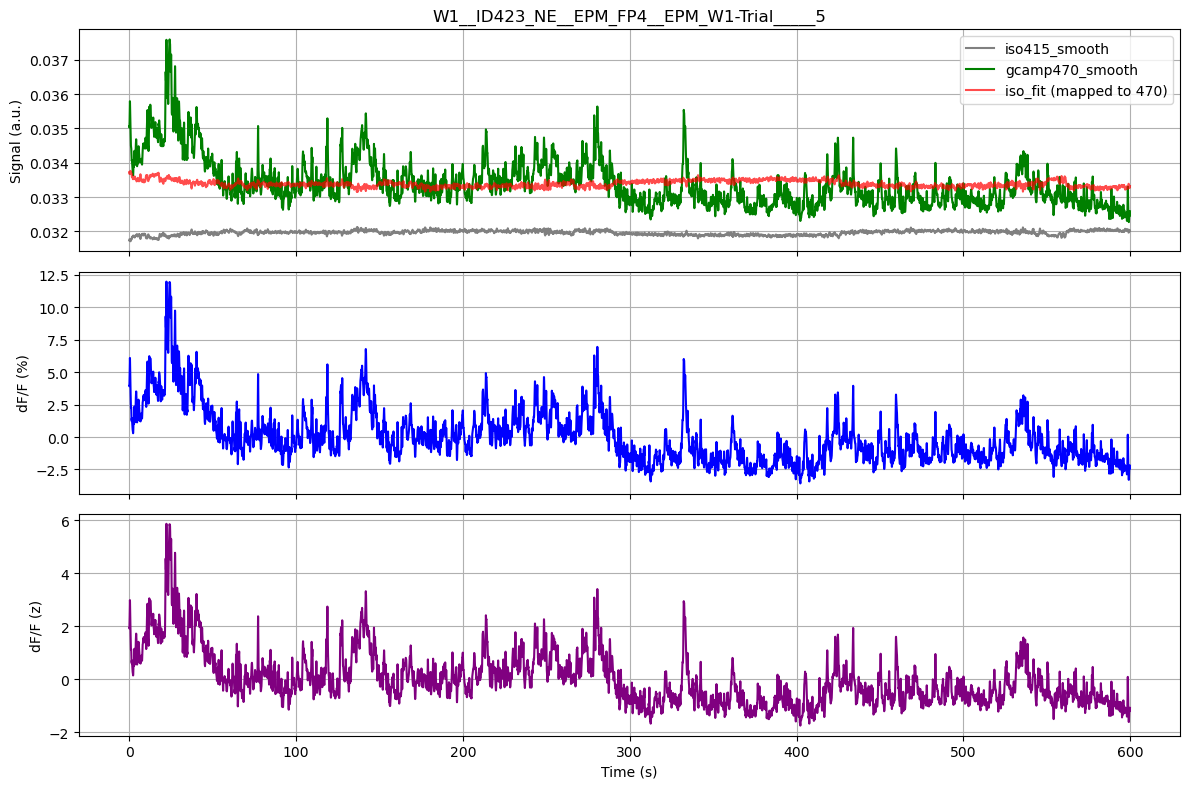

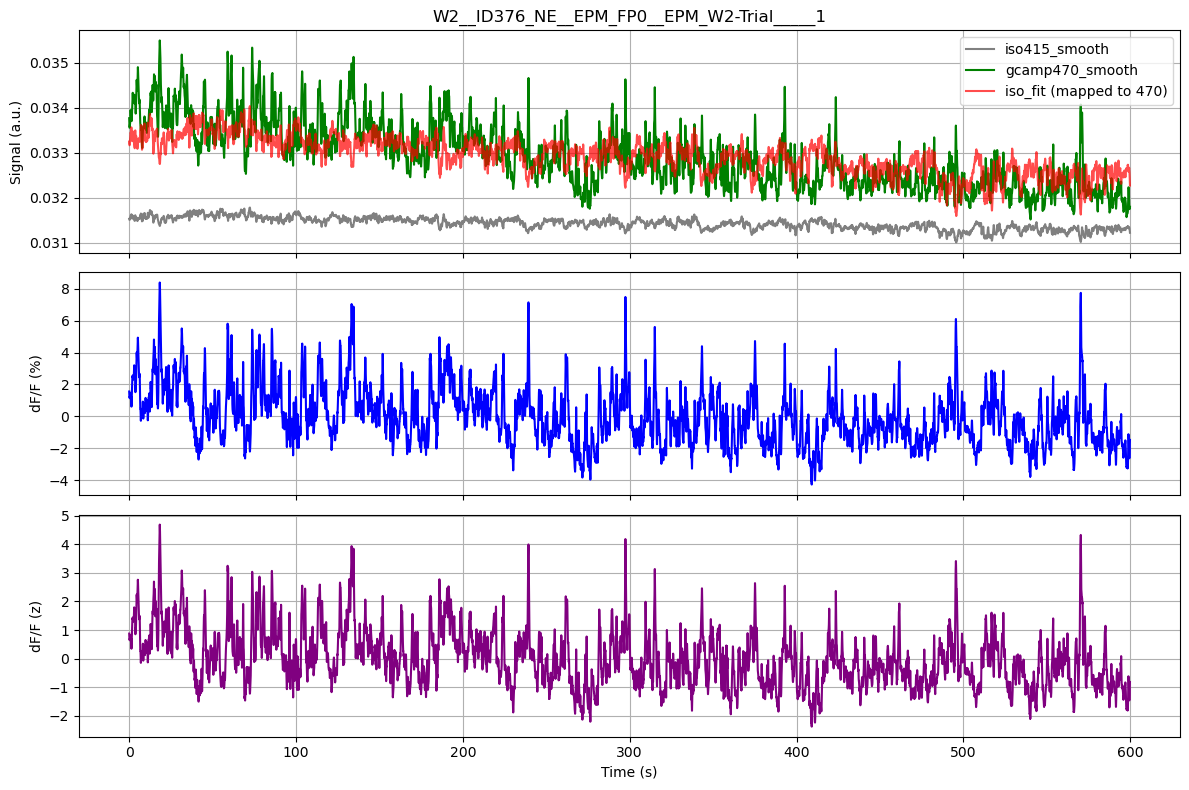

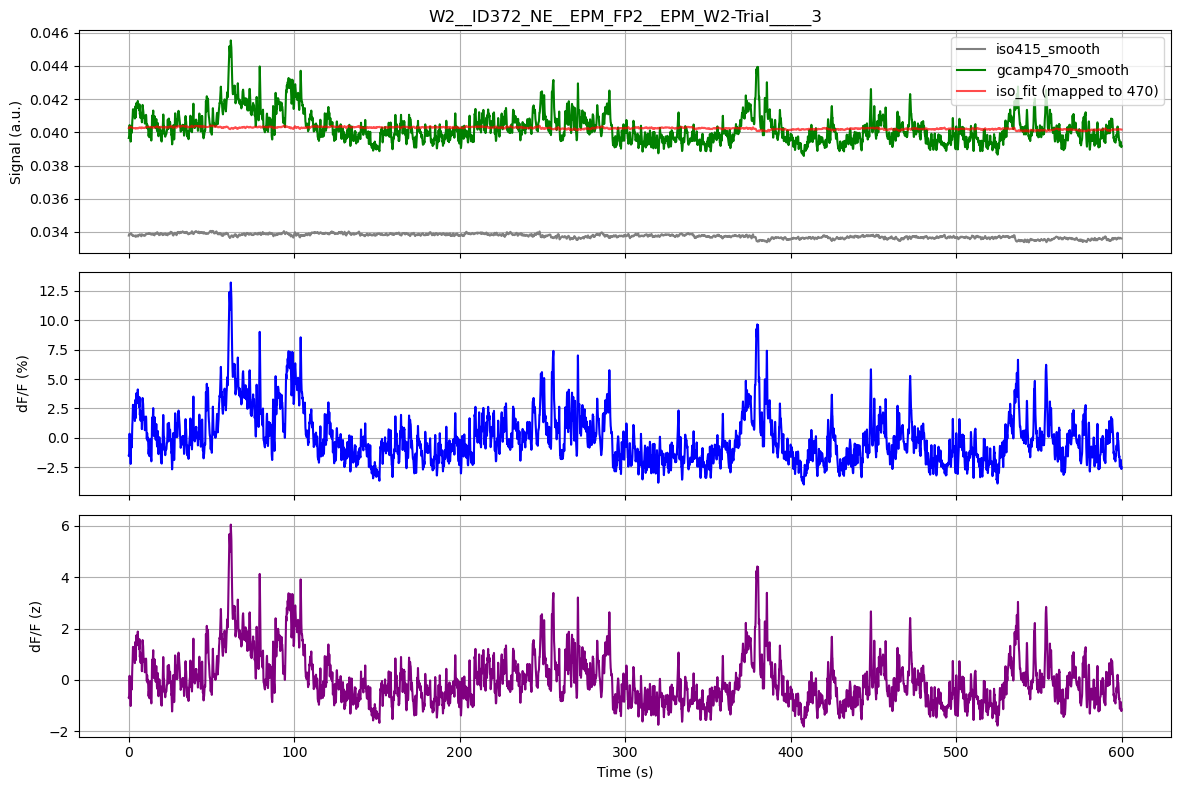

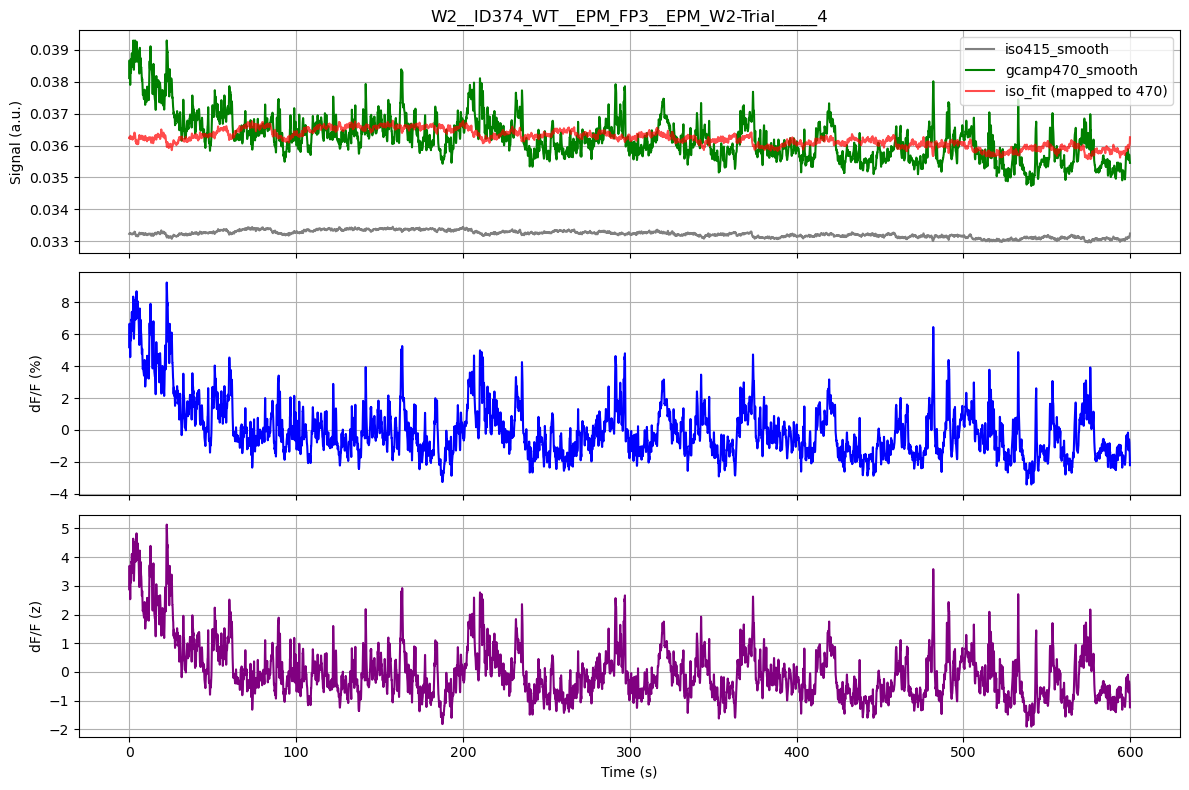

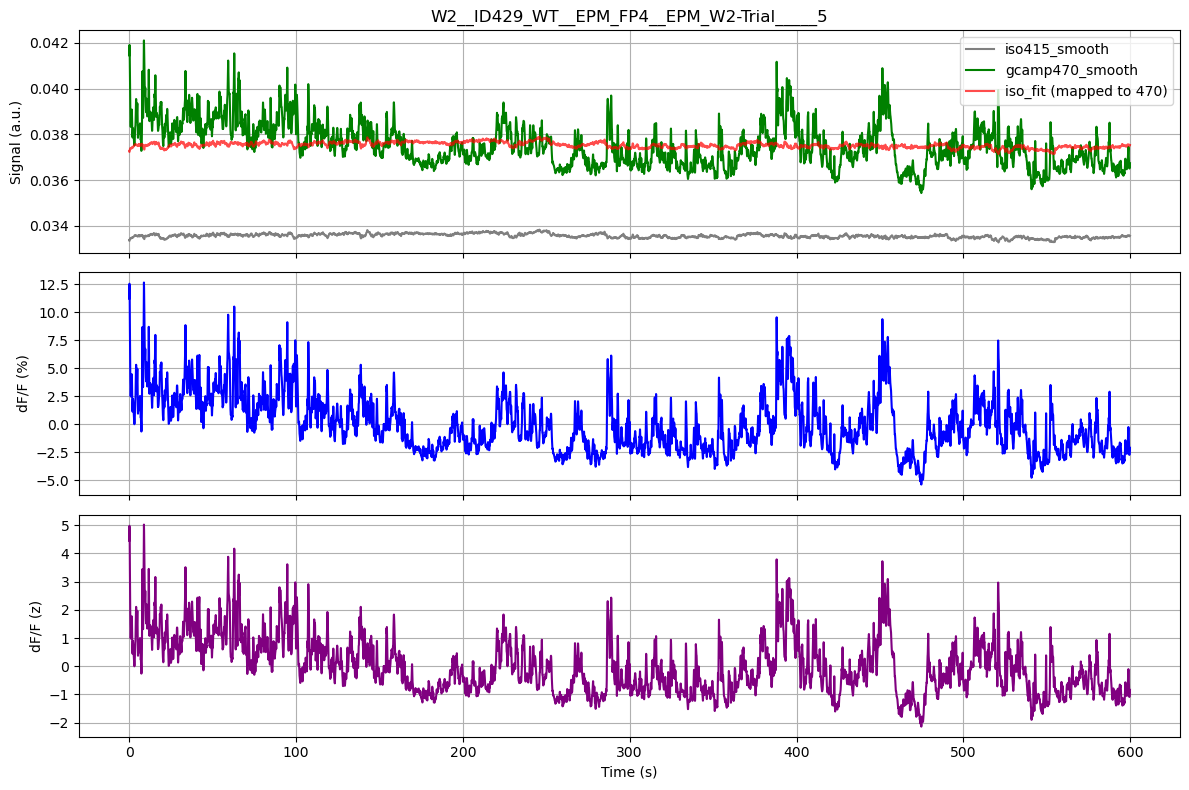

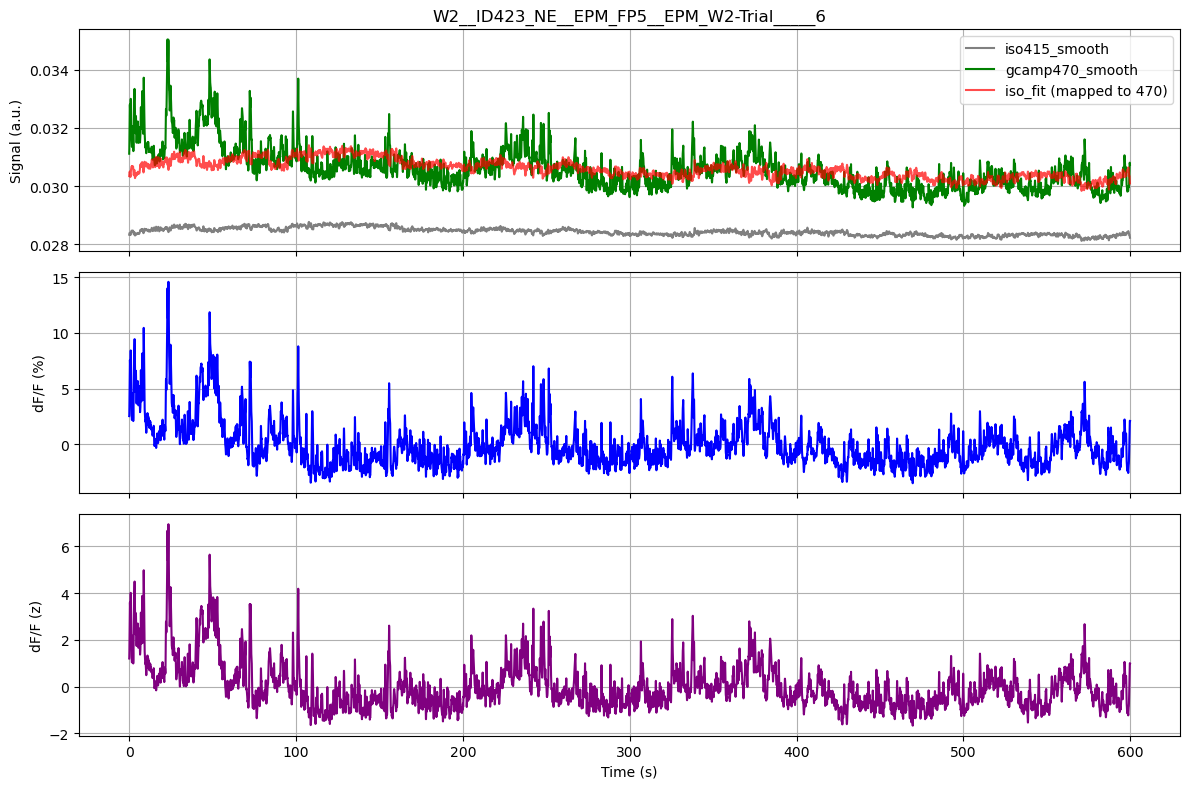

In [24]:
# Plot preprocessed trials with fitted baseline and dF/F
for key in preproc_trials.keys():  # <-- use preproc_trials, not smoothed_trials
    try:
        plot_preproc_trial(preproc_trials[key], key)
    except Exception as e:
        print(f"[WARN] Could not plot {key}: {e}")


# CORRECTIONS TO ETHOVISION ETHOGRAM
I want to look at the ethovision behavioural data. Right now even if the animal quickly 'transitions' between a phase via the center points quickly jumping back and forth between zones, but the animal not actually fully moving - I want to account for those transitions. if the point transitions to another zone for less than 1 second, take that time spent in the given area, and change it to the previous area where the mouse spent more than 1 second. plot the new and old ethogram above and below one another for each mouse

# PERI EVENT PLOTS CORRECTED SIGNAL


In [ ]:
# # ==========================================================
# # RAW 470 PERI-EVENT PLOTS (no correction)
# # Detects entries into C1, C2, O1, O2, Neutral zones
# # ==========================================================
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# # ---------- PARAMETERS ----------
# pre_s      = 2.0    # seconds before event
# post_s     = 4.0    # seconds after event
# min_stay_s = 1.0    # must stay ≥ 1 s in zone after entry
# out_root   = main_dir / "Figures" / "PeriEventRaw"
# out_root.mkdir(parents=True, exist_ok=True)

# # ---------- MAIN LOOP (dFF version) ----------
# relax_edges = False
# save_empty_plots = True
# global_summary = []

# trial_keys = list(preproc_trials.keys())  # preproc_trials from dFF pipeline

# for trial_key in trial_keys:
#     try:
#         fp_id, trial_stub = trial_key.split("__", 1)
#         df_dff = preproc_trials[trial_key]

#         time_vec = np.asarray(df_dff["Time_video"], dtype=float).ravel()
#         dff_vec  = np.asarray(df_dff["dFF"], dtype=float).ravel()
#         if time_vec.size < 3 or dff_vec.size < 3:
#             print(f"[WARN] {trial_key}: not enough samples; skipping")
#             continue
#         fps_eff = 1/np.nanmean(np.diff(time_vec))

#         # EthoVision
#         eth_path = sorted(export_dir.glob(f"Raw data-*{trial_stub}*.xlsx"))[0]
#         eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, target_zone_labels, video_fps)
#         if not matched_cols:
#             print(f"[WARN] {trial_key}: no zone columns found"); continue
#         colmap = _zone_column_map(matched_cols)

#         mouse_dir = out_root / fp_id
#         mouse_had_any = False

#         for zone_key in ["C1","C2","O1","O2","Neutral"]:
#             status = {"mouse": fp_id, "trial": trial_stub, "zone": zone_key}
#             if zone_key not in colmap:
#                 status |= {"rises":0,"pass_stay":0,"within_window":0,"edge_dropped":0,"note":"no_column"}
#                 global_summary.append(status)
#                 if save_empty_plots: _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir, note="No column")
#                 continue

#             arr = _coerce_zone_binary(eth[colmap[zone_key]])
#             rises = int(np.where(np.diff(np.r_[0, arr]) == 1)[0].size)

#             evt_times = _entrance_times(eth, colmap[zone_key], video_fps, min_stay_s)
#             pass_stay = int(evt_times.size)
#             evt_times = np.asarray(evt_times, dtype=float).ravel()

#             if evt_times.size == 0:
#                 if save_empty_plots: _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir, note="No qualifying entries")
#                 status |= {"rises":rises,"pass_stay":pass_stay,"within_window":0,"edge_dropped":0,"note":"no_events"}
#                 global_summary.append(status)
#                 continue

#             ERF, within, edge_dropped = _segments_raw_debug(
#                 time_vec=time_vec, signal_vec=dff_vec, evt_times=evt_times,
#                 pre_s=pre_s, post_s=post_s, fps=fps_eff
#             )

#             status |= {"rises":rises,"pass_stay":pass_stay,"within_window":within,"edge_dropped":edge_dropped,"note":""}
#             global_summary.append(status)

#             if ERF.size > 0:
#                 _plot_peri_raw(fp_id, zone_key, ERF, fps_eff, mouse_dir)
#                 mouse_had_any = True
#             elif save_empty_plots:
#                 _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir, note="No qualifying entries")

#         if mouse_had_any:
#             print(f"✅ Peri-event plots (dFF) saved for {trial_key}")
#         else:
#             print(f"[INFO] No zones plotted for {trial_key}")

#     except Exception as e:
#         print(f"[WARN] {trial_key}: {e}")

# # Write summary CSV
# summary_path = out_root / "ALL_mice_event_summary_dFF.csv"
# pd.DataFrame(global_summary).to_csv(summary_path, index=False)
# print(f"\n[INFO] Wrote summary: {summary_path}")


# PERI EVENT PLOTS UNCORRECTED SIGNAL


In [ ]:
# ==========================================================
# RAW 470 PERI-EVENT PLOTS (no correction)
# Detects entries into C1, C2, O1, O2, Neutral zones
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- PARAMETERS ----------
pre_s      = 2.0    # seconds before event
post_s     = 4.0    # seconds after event
min_stay_s = 1.0    # must stay ≥ 1 s in zone after entry
out_root   = main_dir / "Figures" / "PeriEventRaw"
out_root.mkdir(parents=True, exist_ok=True)

# ---------- SAFE HELPERS ----------
def _coerce_zone_binary(series: pd.Series) -> np.ndarray:
    """Convert EthoVision zone col to 0/1 uint8 (NaNs→0)."""
    vals = pd.to_numeric(series, errors="coerce").fillna(0.0).to_numpy(dtype=float)
    return (vals > 0.5).astype(np.uint8)

def _entrance_times(eth: pd.DataFrame, zone_col: str, fps: float, min_stay_s: float) -> np.ndarray:
    """Return timestamps for valid zone entries (stay ≥ min_stay_s)."""
    arr = _coerce_zone_binary(eth[zone_col])
    dif = np.diff(np.r_[0, arr])           # 1 at 0→1 transitions
    cand_idx = np.where(dif == 1)[0].astype(int)

    min_len = int(round(min_stay_s * fps))
    keep = []
    for i0 in cand_idx:
        j = i0
        while j < arr.size and arr[j] == 1:
            j += 1
        if (j - i0) >= min_len:
            keep.append(i0)

    # Frame-based time (robust to Time_s NaNs)
    t = np.arange(len(eth), dtype=float) / float(fps)
    return t[np.asarray(keep, dtype=int)]

def _best_match_column(available: list[str], wanted_tokens: list[str]) -> str | None:
    norm = {c: c.lower().replace(" ", "") for c in available}
    tokens = [t.lower().replace(" ", "") for t in wanted_tokens]
    for c, nc in norm.items():
        if all(tok in nc for tok in tokens):
            return c
    return None

def _zone_column_map(matched_cols: list[str]) -> dict:
    """Map zone keys (C1,C2,O1,O2,Neutral) → real EthoVision columns."""
    colmap = {}
    exact_targets = {
        "O1": "In zone 2(O1_prevC1 / Center-point)",
        "O2": "In zone 2(O2_prevC2 / Center-point)",
        "C1": "In zone 2(C1_prevO1 / Center-point)",
        "C2": "In zone 2(C2_prevO2 / Center-point)",
        "Neutral": "In zone 2(NeutralZone / Center-point)",
    }
    for k, exact in exact_targets.items():
        if exact in matched_cols:
            colmap[k] = exact
        else:
            toks = ["inzone2", k.lower()] if k in ("O1","O2","C1","C2") else ["inzone2","neutral"]
            g = _best_match_column(matched_cols, toks)
            if g:
                colmap[k] = g
    return colmap

def _collect_segments_raw(time_vec, signal_vec, evt_times, pre_s, post_s, fps):
    """Extract raw peri-event signal windows (no baseline)."""
    pre_n  = int(round(pre_s  * fps))
    post_n = int(round(post_s * fps))
    segs = []
    for ev in evt_times:
        idx = np.searchsorted(time_vec, ev)
        if idx >= pre_n and (idx + post_n) < len(signal_vec):
            segs.append(signal_vec[idx - pre_n : idx + post_n])
    if not segs:
        return np.empty((pre_n + post_n, 0))
    return np.column_stack(segs)

def _plot_peri_raw(mouse_id, zone_key, ERF, fps, out_dir):
    """Plot & save raw peri-event traces."""
    out_dir.mkdir(parents=True, exist_ok=True)
    pre_n, post_n = int(round(pre_s*fps)), int(round(post_s*fps))
    t = np.linspace(-pre_s, post_s, pre_n + post_n, endpoint=False)

    fig, ax = plt.subplots(figsize=(8,4))
    if ERF.shape[1] > 0:
        colors = plt.cm.tab10(np.linspace(0,1,ERF.shape[1]))
        for i,c in enumerate(colors):
            ax.plot(t, ERF[:,i], color=c, alpha=0.35, lw=1)
        ax.plot(t, ERF.mean(1), color="k", lw=2.2, label="Mean")
        ax.legend(frameon=False, loc="upper right")
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set(title=f"{mouse_id}: entry into {zone_key}",
           xlabel="Time rel. to entry (s)",
           ylabel="Raw 470 signal (a.u.)")
    ax.grid(True)
    plt.tight_layout()
    out_png = out_dir / f"{mouse_id}__{zone_key}.png"
    plt.savefig(out_png, dpi=200)
    plt.close(fig)
    return out_png




# ---------- MAIN LOOP (robust, all mice + global summary) ----------
relax_edges = False      # allow partial windows near edges (pads with NaNs)
save_empty_plots = True  # save a stub plot even if no events
global_summary = []      # accumulate across all mice

def _segments_raw_debug(time_vec, signal_vec, evt_times, pre_s, post_s, fps):
    pre_n = int(round(pre_s*fps)); post_n = int(round(post_s*fps))
    n = len(signal_vec)
    ok_events, dropped_edges = 0, 0
    segs = []
    for ev in evt_times:
        idx = np.searchsorted(time_vec, ev)
        left = idx - pre_n; right = idx + post_n
        if left < 0 or right >= n:
            if relax_edges:
                left = max(0, left); right = min(n, right)
                seg = signal_vec[left:right].copy()
                L = pre_n + post_n
                if seg.size < L:
                    seg = np.concatenate([seg, np.full(L - seg.size, np.nan)])
                segs.append(seg); ok_events += 1
            else:
                dropped_edges += 1
            continue
        segs.append(signal_vec[left:right]); ok_events += 1
    ERF = np.column_stack(segs) if segs else np.empty((pre_n + post_n, 0))
    return ERF, ok_events, dropped_edges

def _plot_empty_stub(mouse_id, zone_key, fps, out_dir, note="No qualifying entries"):
    out_dir.mkdir(parents=True, exist_ok=True)
    pre_n = int(round(pre_s*fps)); post_n = int(round(post_s*fps))
    t = np.linspace(-pre_s, post_s, pre_n + post_n, endpoint=False)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.text(0.02, 0.9, note, transform=ax.transAxes)
    ax.set(title=f"{mouse_id}: entry into {zone_key}",
           xlabel="Time rel. to entry (s)", ylabel="Raw 470 signal (a.u.)")
    ax.grid(True)
    plt.tight_layout()
    out_png = out_root / mouse_id / f"{mouse_id}__{zone_key}.png"
    plt.savefig(out_png, dpi=200); plt.close(fig)

trial_files = sorted(export_dir.glob("Raw data-*.xlsx"))
print(f"[INFO] Found {len(trial_files)} trials")
for i_trial, eth_path in enumerate(trial_files, 1):
    try:
        fp_id = _read_export_and_get_fp_id(eth_path)
        print(f"\n--- [{i_trial}/{len(trial_files)}] {eth_path.name} → {fp_id} ---")

        # FP trim
        fp_folder = main_dir / fp_id
        fp_csv, ts_csv = _find_fp_and_timestamp_files(fp_folder, fp_id)
        fp = pd.read_csv(fp_csv); fp = fp[fp["LedState"].isin([1,2])].copy()
        ts = pd.read_csv(ts_csv)
        start, stop = _get_video_window(ts)
        fp_trim = _trim_fp_to_window(fp, start=start, stop=stop)

        # LED2 channel/time
        gmask = fp_trim["LedState"] == 2
        g_time = fp_trim.loc[gmask,"Time_video"].to_numpy(float)
        if g_time.size < 3:
            print("[WARN] LED2 has too few samples; skipping")
            continue
        fps_eff = 1/np.mean(np.diff(g_time))
        chan = "G0" if "G0" in fp_trim.columns else next(
            c for c in fp_trim.columns
            if pd.api.types.is_numeric_dtype(fp_trim[c])
            and c not in {"SystemTimestamp","LedState","Time_video","Time_s","Timestamp"}
        )
        raw470 = fp_trim.loc[gmask, chan].to_numpy(float)

        # EthoVision
        eth, matched_cols = _load_ethovision_sheet_with_targets(eth_path, target_zone_labels, video_fps)
        print(f"[INFO] matched_cols: {matched_cols}")
        if not matched_cols:
            print("[WARN] No zone cols found"); continue
        colmap = _zone_column_map(matched_cols)
        print(f"[INFO] colmap: {colmap}")
        if not colmap:
            print("[WARN] Zone mapping failed"); continue

        mouse_dir = out_root / fp_id
        mouse_had_any = False

        for zone_key in ["C1","C2","O1","O2","Neutral"]:
            status = {"mouse": fp_id, "trial": eth_path.name, "zone": zone_key}
            if zone_key not in colmap:
                print(f"[INFO] {zone_key}: column not present"); 
                status |= {"rises":0,"pass_stay":0,"within_window":0,"edge_dropped":0,"note":"no_column"}
                global_summary.append(status)
                if save_empty_plots: _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir)
                continue

            # raw rises
            arr = _coerce_zone_binary(eth[colmap[zone_key]])
            rises = int(np.where(np.diff(np.r_[0, arr]) == 1)[0].size)
            # pass 1s stay
            idx_keep = _entrance_times(eth, colmap[zone_key], video_fps, min_stay_s)
            pass_stay = int(idx_keep.size)
            evt_times = idx_keep  # already timestamps from _entrance_times

            # segments and edge drops
            ERF, within, edge_dropped = _segments_raw_debug(
                time_vec=g_time, signal_vec=raw470, evt_times=evt_times,
                pre_s=pre_s, post_s=post_s, fps=fps_eff
            )
            print(f"[{fp_id} {zone_key}] rises={rises}, pass_stay={pass_stay}, "
                  f"within_window={within}, edge_dropped={edge_dropped}")

            status |= {"rises":rises, "pass_stay":pass_stay,
                       "within_window":within, "edge_dropped":edge_dropped,
                       "note":""}
            global_summary.append(status)

            if ERF.size == 0:
                if save_empty_plots:
                    _plot_empty_stub(fp_id, zone_key, fps_eff, mouse_dir,
                                     note="No qualifying entries")
                continue

            _plot_peri_raw(fp_id, zone_key, ERF, fps_eff, mouse_dir)
            mouse_had_any = True

        if mouse_had_any:
            print(f"✅ Peri-event plots saved in {mouse_dir}")
        else:
            print(f"[INFO] No zones plotted for {fp_id} (empty or filtered); stub images may exist")

    except Exception as e:
        print(f"[WARN] {eth_path.name}: {e}")

# Write a single CSV with all mice/zones
summary_path = out_root / "ALL_mice_event_summary.csv"
pd.DataFrame(global_summary).to_csv(summary_path, index=False)
print(f"\n[INFO] Wrote summary: {summary_path}")
